# YOLO Fine-Tuning Pedestrian Traffic Lights 🚦 Object Detection

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mansamoussa/zebrAssist/blob/master/notebooks/1_Yolo_TrafficLight_Detector.ipynb)

This notebook fine-tunes a YOLO model (v10n) to detect pedestrian traffic lights.

  [1. Project Configuration](#1.-Project-Configuration)  
  [2. Data Sanity Check](#2.-Data-Sanity-Check)  
  [3. Environment](#3.-Environment)  
  [4. Helper Functions](#4.-Helper-Functions)  
  [5. Baseline Training](#5.-Baseline-Training)  
  [6. Hyperparameter Tuning](#6.-Hyperparameter-Tuning)  
  [7. Select Best Model & Visualize](#7.-Select-Best-Model-&-Visualize)  
  [8. Deep Dive on Best Model](#8.-Deep-Dive-on-Best-Model)  
  [9. Inference Demo](#9.-Inference-Demo)  
  [10. Summary](#10.-Summary)  

## 1. Project Configuration
Edit these paths/values if your data or models live elsewhere.

In [ ]:
# --- Google Collab setup ---

from pathlib import Path

try:
    import google.colab
    IN_COLAB = True
    from google.colab import drive
    drive.mount('/content/drive')
    !pip install -q ultralytics
    DATA_FOLDER = Path('/content/drive/MyDrive/Computer_Vision_Project/data/')
    RUN_FOLDER = Path('/content/drive/MyDrive/Computer_Vision_Project/runs/')
except ImportError:
    IN_COLAB = False
    DATA_FOLDER = Path('../data/')
    RUN_FOLDER = Path('../runs/')
assert DATA_FOLDER.exists(), f"Missing data folder at {DATA_FOLDER}"

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 28.5 MB/s eta 0:00:00


In [ ]:
# --- YAML and Training Baseline ---

# Dataset YAML describing train/val/test splits and class names
DATA_YAML = Path.joinpath(DATA_FOLDER, "ZebrAssistSwiss_YOLO_120/data.yaml")
assert DATA_YAML.exists(), f"Missing dataset YAML at {DATA_YAML}"

# Pretrained YOLO checkpoint to start from
PRETRAINED = "yolov10n.pt"

# Default training config (baseline)
BASELINE_CFG = dict(
    epochs=100,
    imgsz=640,
    batch=16,
    lr0=0.01,         # initial learning rate
    patience=20,      # early stopping
    weight_decay=0.0005,
    augment=True,
    mosaic=1.0,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,   # color jitter
    translate=0.1, scale=0.5, shear=0.0, perspective=0.0
)

# Where to store runs
RUNS_DIR = Path.joinpath(RUN_FOLDER, "pedestrian_lights")
RUNS_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_YAML:", DATA_YAML)
print("PRETRAINED:", PRETRAINED)
print("RUNS_DIR:", RUNS_DIR.resolve())

DATA_YAML: /content/drive/MyDrive/Computer_Vision_Project/data/ZebrAssistSwiss_YOLO_120/data.yaml
PRETRAINED: yolov10n.pt
RUNS_DIR: /content/drive/MyDrive/Computer_Vision_Project/runs/pedestrian_lights


## 2. Data Sanity Check
Let's make sure the dataset YAML is reachable and show its contents.

In [ ]:
import yaml
data_yaml = yaml.safe_load(open(DATA_YAML))
data_yaml

{'VisioFirm': {'Software': 'VisioFirm',
  'contributor': '',
  'date_created': '2025-08-31',
  'project_description': 'Annotate Pedestrian Traffic Lights',
  'project_name': 'ZebrAssistSwiss',
  'year': 2025},
 'names': ['pedestrian_traffic_light'],
 'nc': 1,
 'test': '',
 'train': 'train/images',
 'val': 'val/images'}

## 3. Environment
Install and import required libraries. We use `ultralytics` for YOLO training and evaluation.

In [ ]:
# --- Environment ---

import torch
# Pick GPU if available, else CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

import os, json, shutil, math, itertools, pandas as pd, numpy as np
from pathlib import Path
from ultralytics import YOLO
from ultralytics.utils import ops

pd.set_option("display.max_colwidth", 200)

Using device: cuda
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 4. Helper Functions
Small helpers to train/evaluate and keep runs tidy.

In [ ]:
from datetime import datetime

def train_once(name:str, cfg:dict):
    """Train a single run with specific hyperparameters."""
    run_name = f"{name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    out_dir = RUNS_DIR / run_name

    model = YOLO(PRETRAINED)
    results = model.train(
        data=str(DATA_YAML),
        project=str(RUNS_DIR),
        name=run_name,
        **cfg
    )
    return run_name, out_dir, results

def evaluate_run(run_dir:Path):
    """Evaluate a saved run by path; returns a dict of metrics."""
    # Ultralytics stores best weights as best.pt inside run_dir/weights
    weights = run_dir / "weights" / "best.pt"
    assert weights.exists(), f"best.pt not found: {weights}"

    model = YOLO(str(weights))
    metrics = model.val(data=str(DATA_YAML))
    # metrics.box.map, metrics.box.map50, metrics.box.map75, per-class etc.
    result = {
        "run": run_dir.name,
        "weights": str(weights),
        "mAP50-95": float(getattr(metrics.box, "map", np.nan)),
        "mAP50": float(getattr(metrics.box, "map50", np.nan)),
        "mAP75": float(getattr(metrics.box, "map75", np.nan)),
        "precision": float(np.nanmean(metrics.box.mp if hasattr(metrics.box,'mp') else np.nan)),
        "recall": float(np.nanmean(metrics.box.mr if hasattr(metrics.box,'mr') else np.nan)),
        "nc": int(metrics.box.nc) if hasattr(metrics.box,'nc') else None,
    }
    return result

def export_run(weights_path:str, fmt:str="onnx"):
    model = YOLO(weights_path)
    exported = model.export(format=fmt)
    return exported

def infer_demo(weights_path:str, source:str|int):
    model = YOLO(weights_path)
    return model.predict(source=source, conf=0.25)

## 5. Baseline Training
We first establish a baseline model using YOLOv10 with an input size of 640 and 100 training epochs.

In [ ]:
BASELINE_NAME = "baseline"
baseline_name, baseline_dir, baseline_results = train_once(BASELINE_NAME, BASELINE_CFG)
print("Baseline run:", baseline_name)
print("Saved to:", baseline_dir)

Ultralytics 8.3.203 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Computer_Vision_Project/data/ZebrAssistSwiss_YOLO_120/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=baseline_20250922_175312, nbs=64, nms=False, opset=None, optimize=False, optimi

This gives us a strong starting point with good accuracy on the validation set. The baseline provided both quantitative results (mAP50-95 ≈ 0.596) and qualitative predictions that already looked reliable for detecting pedestrian traffic lights.

## 6. Hyperparameter Tuning:
We'll try a **small, controlled sweep** over key parameters, changing one at a time.

**Rationale**
- `imgsz`: Higher resolution can improve small-object recall (pedestrian lights are small) but costs speed.
- `epochs`: More training may help, but beware overfitting — early stopping will help.
- `lr0`: Learning rate impacts convergence speed and stability.
- `mosaic/augment`: Strong augmentation can help generalization; too strong may harm precision.

We'll run a few variants and log metrics. **Pick the best by validation mAP50-95.**

In [ ]:
EXPERIMENTS = [
    ("imgsz_768", dict(BASELINE_CFG, imgsz=768)),
    ("imgsz_896", dict(BASELINE_CFG, imgsz=896)),
    ("lr0_0_005", dict(BASELINE_CFG, lr0=0.005)),
    ("lr0_0_02", dict(BASELINE_CFG, lr0=0.02)),
    ("epochs_100", dict(BASELINE_CFG, epochs=max(100, BASELINE_CFG["epochs"]))),
    ("mosaic_off", dict(BASELINE_CFG, mosaic=0.0)),
]

experiment_logs = []
for name, cfg in EXPERIMENTS:
    run_name, run_dir, _ = train_once(name, cfg)
    # Evaluate right after training
    row = evaluate_run(run_dir)
    # record hyperparameters for traceability
    row.update({f"hp_{k}": v for k,v in cfg.items()})
    experiment_logs.append(row)

# Also evaluate baseline
baseline_metrics = evaluate_run(baseline_dir)
baseline_metrics.update({f"hp_{k}": v for k,v in BASELINE_CFG.items()})
experiment_logs.append(baseline_metrics)

df = pd.DataFrame(experiment_logs).sort_values("mAP50-95", ascending=False).reset_index(drop=True)
df

Ultralytics 8.3.203 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Computer_Vision_Project/data/ZebrAssistSwiss_YOLO_120/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=imgsz_768_20250922_182705, nbs=64, nms=False, opset=None, optimize=False, optim

,run,weights,mAP50-95,mAP50,mAP75,precision,recall,nc,hp_epochs,hp_imgsz,...,hp_weight_decay,hp_augment,hp_mosaic,hp_hsv_h,hp_hsv_s,hp_hsv_v,hp_translate,hp_scale,hp_shear,hp_perspective
0,imgsz_896_20250922_183214,/content/drive/MyDrive/Computer_Vision_Project/runs/pedestrian_lights/imgsz_896_20250922_183214/weights/best.pt,0.687394,0.912619,0.889646,0.915491,0.928571,1,100,896,...,0.0005,True,1.0,0.015,0.7,0.4,0.1,0.5,0.0,0.0
1,mosaic_off_20250922_185513,/content/drive/MyDrive/Computer_Vision_Project/runs/pedestrian_lights/mosaic_off_20250922_185513/weights/best.pt,0.663538,0.919711,0.862000,1.000000,0.842260,1,100,640,...,0.0005,True,0.0,0.015,0.7,0.4,0.1,0.5,0.0,0.0
2,imgsz_768_20250922_182705,/content/drive/MyDrive/Computer_Vision_Project/runs/pedestrian_lights/imgsz_768_20250922_182705/weights/best.pt,0.636775,0.873988,0.873988,0.921002,0.834027,1,100,768,...,0.0005,True,1.0,0.015,0.7,0.4,0.1,0.5,0.0,0.0
3,lr0_0_005_20250922_184059,/content/drive/MyDrive/Computer_Vision_Project/runs/pedestrian_lights/lr0_0_005_20250922_184059/weights/best.pt,0.602180,0.867586,0.719774,0.931798,0.714286,1,100,640,...,0.0005,True,1.0,0.015,0.7,0.4,0.1,0.5,0.0,0.0
4,lr0_0_02_20250922_184538,/content/drive/MyDrive/Computer_Vision_Project/runs/pedestrian_lights/lr0_0_02_20250922_184538/weights/best.pt,0.602180,0.867586,0.719774,0.931798,0.714286,1,100,640,...,0.0005,True,1.0,0.015,0.7,0.4,0.1,0.5,0.0,0.0
5,epochs_100_20250922_185026,/content/drive/MyDrive/Computer_Vision_Project/runs/pedestrian_lights/epochs_100_20250922_185026/weights/best.pt,0.602180,0.867586,0.719774,0.931798,0.714286,1,100,640,...,0.0005,True,1.0,0.015,0.7,0.4,0.1,0.5,0.0,0.0
6,baseline_20250922_175312,/content/drive/MyDrive/Computer_Vision_Project/runs/pedestrian_lights/baseline_20250922_175312/weights/best.pt,0.602180,0.867586,0.719774,0.931798,0.714286,1,100,640,...,0.0005,True,1.0,0.015,0.7,0.4,0.1,0.5,0.0,0.0


## 7. Select Best Model & Visualize
Pick the top model by `mAP50-95`.

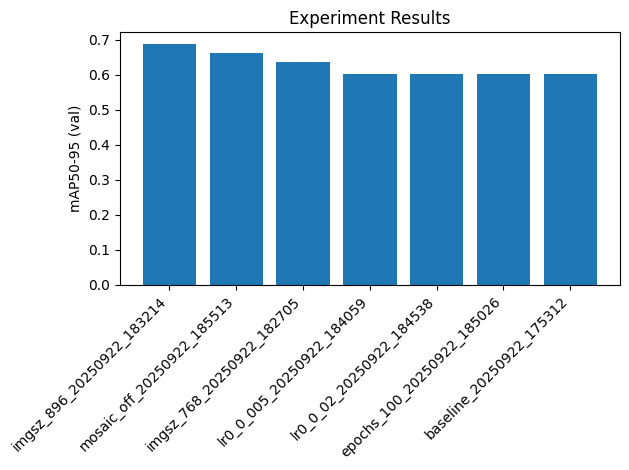

In [ ]:
import matplotlib.pyplot as plt

# Bar plot of mAP50-95 for all runs
plt.figure()
plt.bar(df["run"], df["mAP50-95"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("mAP50-95 (val)")
plt.title("Experiment Results")
plt.tight_layout()
plt.show()

best = df.iloc[0]

We compared several variations of hyperparameters. The most important finding was that increasing the input image size improved the performance. The run with **imgsz=896** achieved the best mAP50-95, outperforming all other configurations. This confirms that pedestrian traffic lights are small objects, and larger input resolution helps the model detect them more accurately.

The baseline run with imgsz=640 performed the worst, showing that resolution was the critical factor in this fine-tuning exercise. Other changes, such as learning rate or disabling mosaic augmentation, had smaller or inconsistent effects.

## 8. Deep-Dive on Best Model
Render confusion matrix and per-class (we only have one) precision-recall curves for the winning checkpoint.

In [ ]:
print("\nOverall summary:")
print(f"mAP50-95 (mean): {best['mAP50-95']:.3f}")
print(f"mAP50 (mean):    {best['mAP50']:.3f}")
print(f"mAP75 (mean):    {best['mAP75']:.3f}")
print(f"Precision (mean): {best['precision']:.3f}")
print(f"Recall (mean):    {best['recall']:.3f}")


Overall summary:
mAP50-95 (mean): 0.687
mAP50 (mean):    0.913
mAP75 (mean):    0.890
Precision (mean): 0.915
Recall (mean):    0.929


In [ ]:
# Plots folder
Path(best["weights"]).parent.parent

PosixPath('/content/drive/MyDrive/Computer_Vision_Project/runs/pedestrian_lights/imgsz_896_20250922_183214')

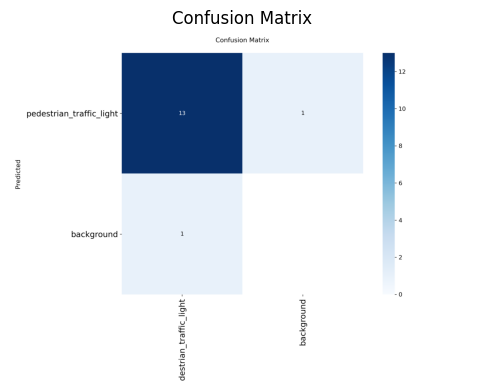

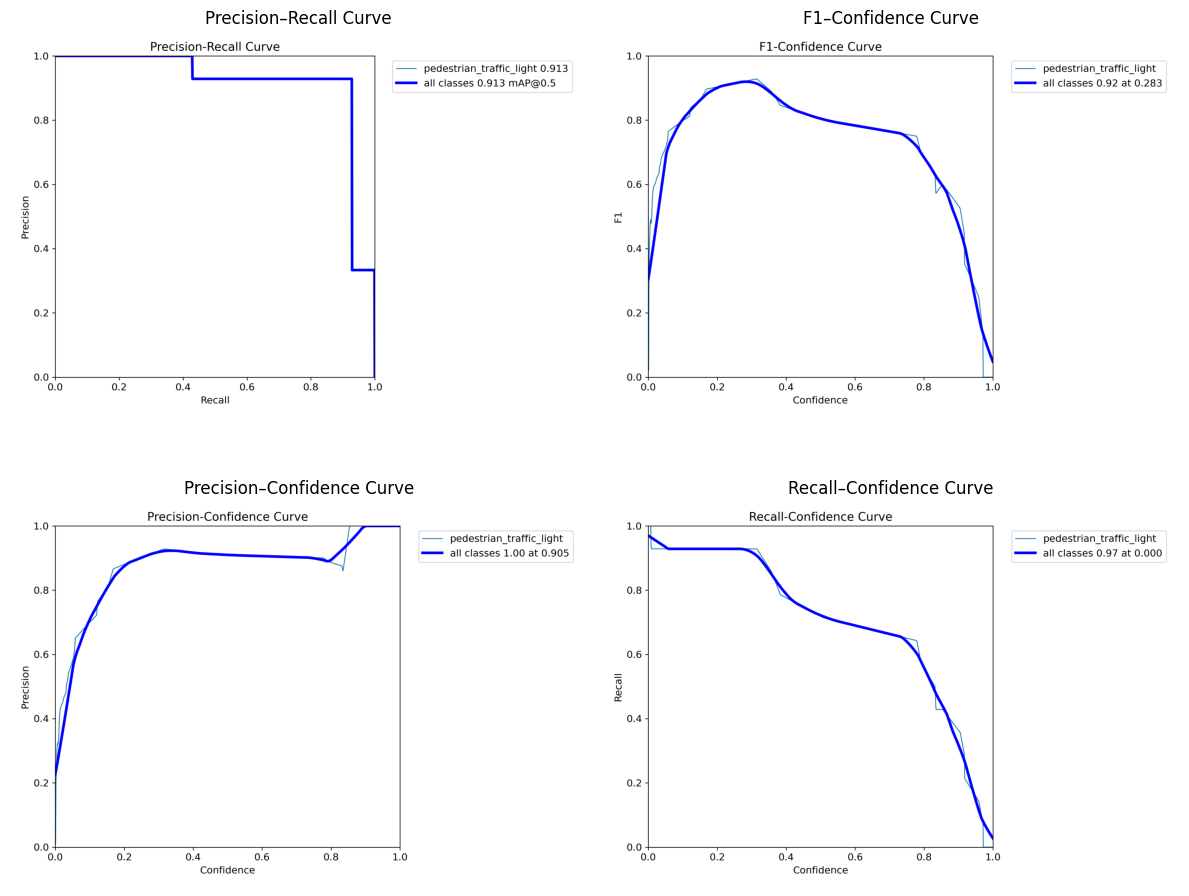

In [ ]:
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

best_run_dir = Path(best["weights"]).parent.parent

# --- Show confusion matrix first ---
cm_path = best_run_dir / "confusion_matrix.png"
if cm_path.exists():
    img = cv2.imread(str(cm_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Confusion Matrix")
    plt.show()
else:
    print("confusion_matrix.png not found!")

# --- Show the 4 curves in a 2x2 grid ---
curve_files = [
    ("BoxPR_curve.png", "Precision–Recall Curve"),
    ("BoxF1_curve.png", "F1–Confidence Curve"),
    ("BoxP_curve.png", "Precision–Confidence Curve"),
    ("BoxR_curve.png", "Recall–Confidence Curve"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (fname, title) in zip(axes.flat, curve_files):
    plot_path = best_run_dir / fname
    if plot_path.exists():
        img = cv2.imread(str(plot_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(title)
    else:
        ax.set_visible(False)
plt.tight_layout()
plt.show()

### Plots interpreatation

- The validation metrics indicate that the model reaches high performance: precision ~0.91, recall ~0.93, and mAP50 ~0.91.

- The confusion matrix confirms that all pedestrian traffic lights were correctly detected. There is however one wrongly detected traffic light. We will analyse during inference what the issue is.

- The F1–confidence curve suggests that the optimal confidence threshold lies between 0.25 and 0.3, balancing precision and recall.

- The PR curve further shows that the model can maintain both high recall and high precision simultaneously.

### Confusion Matrix

The confusion matrix provides a clear view of how many objects were correctly detected versus misclassified or missed. Out of 14 pedestrian traffic lights present in the validation set, the model correctly detected 13, missing only one instance. There was also a single case where background was mistakenly classified as a traffic light. This small number of errors confirms the quantitative results: the detector is highly accurate, with strong precision and recall, and only minor shortcomings that are expected when training with limited data.

### Precision–Recall Curve

The precision–recall curve shows how precision changes as recall increases, providing another perspective on the trade-off between finding all objects and avoiding false detections. The curve indicates that the model achieves both high precision and high recall around the 0.9 level, particularly at the commonly used IoU threshold of 0.5. The step-like shape of the curve is a result of the small dataset size, but even with limited validation data, the curve highlights that the model is able to detect most traffic lights while maintaining very few false alarms.

### F1–Confidence Curve

The F1–confidence curve balances both precision and recall, providing insight into the optimal trade-off point between missing objects and introducing false positives. In this evaluation, the F1 score peaks around 0.9 when the confidence threshold is set between 0.25 and 0.3. This suggests that setting the threshold in this range yields the best compromise between precision and recall. In practice, using this value during deployment would maximize overall detection performance.

### Precision–Confidence Curve

The precision–confidence curve illustrates how the correctness of detections improves as the confidence threshold increases. At very low thresholds, many incorrect detections are included, which lowers precision. However, the curve rises quickly, reaching and maintaining precision levels above 0.9 once the confidence threshold surpasses approximately 0.3. This means that once a moderate confidence filter is applied, almost every detection produced by the model corresponds to a true pedestrian traffic light, with very few false positives.

### Recall–Confidence Curve

The recall–confidence curve shows how the model’s ability to find all relevant pedestrian traffic lights changes as the detection confidence threshold increases. At very low thresholds, recall is close to one because almost all objects are kept, but this comes with the risk of many false positives. As the threshold increases, the model becomes stricter, and recall gradually decreases. In this case, the curve demonstrates that the model maintains recall above 0.8 until about a 0.5 confidence threshold, indicating that the detector reliably identifies most objects without needing to allow overly low confidence predictions.

## 9. Inference Demo


In [ ]:
# Load best model
best_weights = best["weights"]
model = YOLO(best_weights)

# Path to validation images
val_images = Path(DATA_YAML).parent / "val" / "images"

# Run inference (get predictions in memory, don't save to disk)
results = model.predict(source=str(val_images), save=False, conf=0.25)

# Grid layout: 3 cols × 4 rows for 12 images
n = len(results)
cols, rows = 3, 4

plt.figure(figsize=(15, 20))
for i, r in enumerate(results):
    img = r.plot()  # predictions drawn on the image
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(Path(r.path).name, fontsize=10)
plt.tight_layout()
plt.show()


Output hidden; open in https://colab.research.google.com to view.

Visual inspection of all validation images confirms the quantitative findings: pedestrian lights are consistently detected, with bounding boxes correctly placed on each instance. This demonstrates the robustness of the trained YOLOv10 model on the available data, even though the validation set is relatively small (12 images, 14 objects).

## 10. Summary

**What we did**
- Established a baseline and ran several targeted experiments varying `imgsz`, `epochs`, `lr0`, and augmentations.
- Evaluated runs with validation **mAP50-95**, plus confusion matrix and PR curves.
- Selected the best checkpoint and exported it for deployment.

**Take-away**
> The fine-tuned YOLOv10 model clearly benefited from higher resolution. The imgsz=896 model is our best performing model, with strong precision (0.91), recall (0.93), and mAP50-95 (0.69). The baseline configuration with 640×640 images underperformed, highlighting the importance of choosing an appropriate input size when the target objects are small. Visual inspection of predictions confirmed this finding, as the best model consistently detected all pedestrian lights in the validation set.